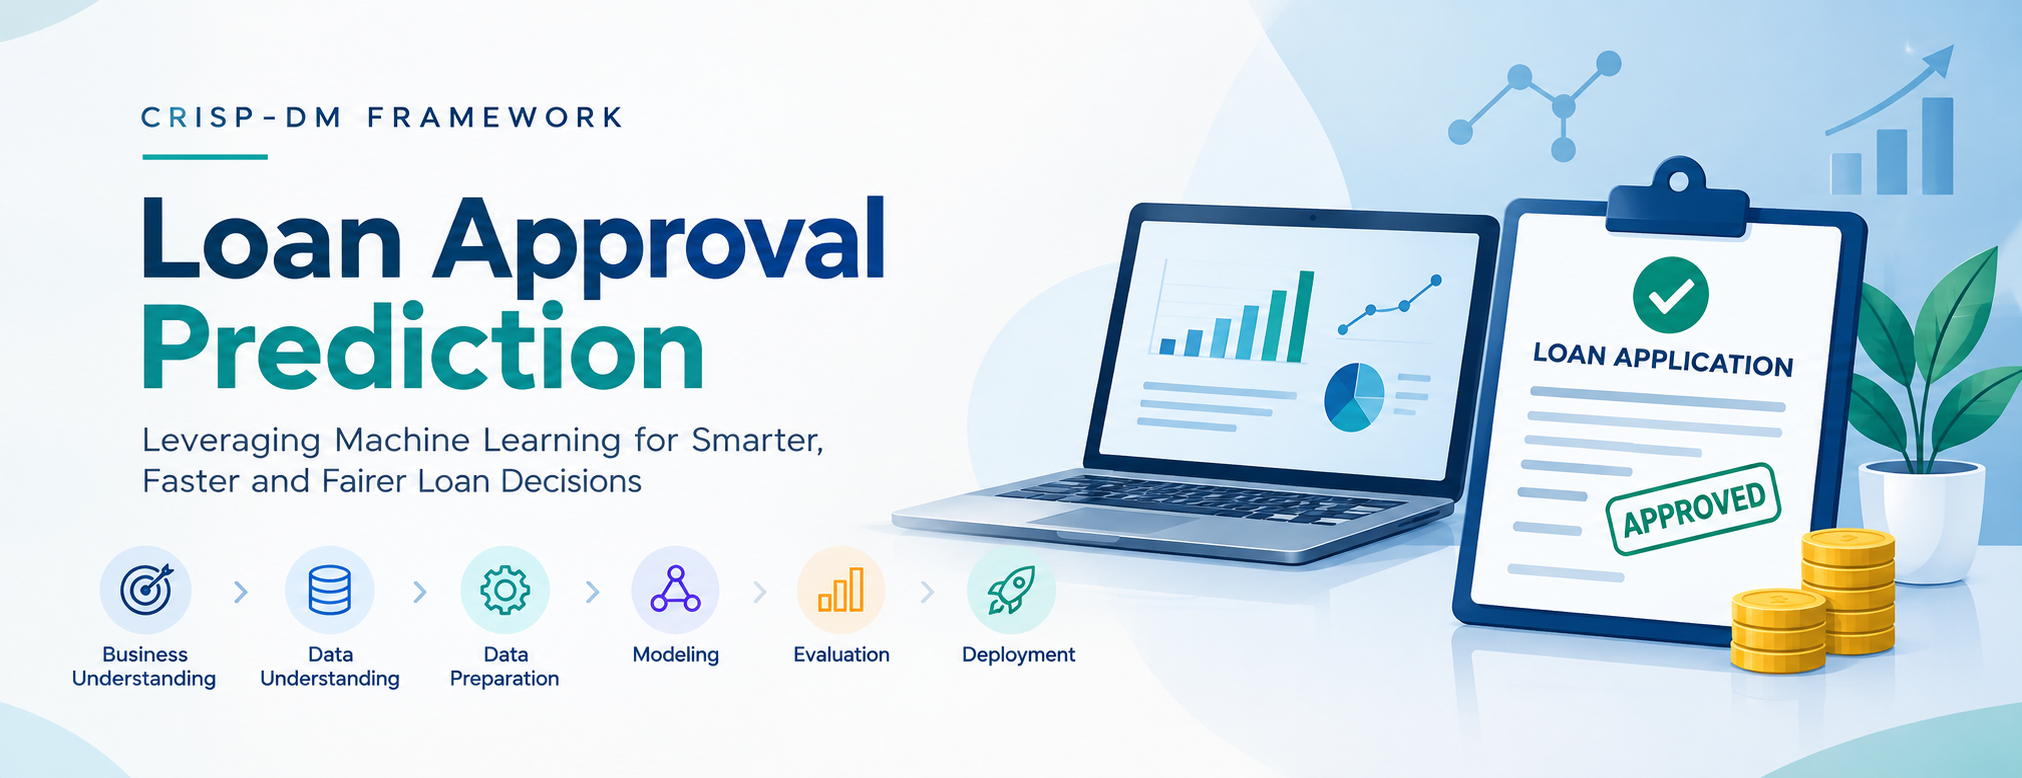](path/url/to/image)
- Banner/header image.
![Loan Approval and Machine Learning](wide_clean_modern_infographic_style_banner_image.png)

# Title
- Relevant to Data and Business Context
- # Machine Learning Model for Loan Approval

### Using Data-Driven Insights to Support Faster, Consistent, and Risk-Aware Loan Decisions

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'
- This project aims to build a machine learning classification model to help FinTech Innovations make better loan approval decisions.

The dataset contains information about previous loan applicants and whether their loans were approved or denied. The data will be cleaned and preprocessed, then different classification models will be trained and compared. The models will be evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and business cost.

The main business concern is that approving a loan that later defaults can cause a $50,000 loss, while denying a creditworthy applicant can result in an $8,000 lost profit. Therefore, the model should reduce risky approvals while still identifying suitable applicants.

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

Business Context

FinTech Innovations uses manual loan reviews, which can be slow and lead to inconsistent decisions. Machine learning can help improve decision-making, reduce bias, and speed up the approval process.

Key stakeholders: Loan officers need faster and consistent assessments, management wants to reduce financial losses, customers need fair decisions, and the compliance team requires transparency.

Model errors: A false positive means approving a loan that defaults, causing a $50,000 loss. A false negative means denying a creditworthy applicant, resulting in $8,000 lost profit.

Model choice: I chose classification to predict whether an applicant is likely to default or repay. The predicted risk can help loan officers make informed approval decisions.


2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


Modeling Goals and Success Criteria

The goal is to build a reliable model that identifies loan default risk while reducing financial losses.

Precision: Measures how many predicted defaults are actual defaults, helping assess risky approvals.

Recall: Measures how many actual defaults the model identifies, helping reduce missed risky loans.

ROC-AUC: Measures how well the model separates defaulters from non-defaulters.

Custom business cost: Calculates the estimated cost of false approvals and false denials.

Total Cost=(50,000×FP)+(8,000×FN)

Baseline targets:

ROC-AUC ≥ 0.75

Default recall ≥ 0.80

Default precision ≥ 0.60

Lower business cost than the baseline model.

These are initial targets. I will compare the models using cross-validation and test data to identify a suitable model based on performance, business cost, and interpretability.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

Exploratory Data Analysis (EDA)

I will explore the dataset to understand its structure, identify patterns, and check data quality before modeling.

Check the number of rows, columns, data types, and summary statistics.

Examine feature distributions and the target class balance.

Use histograms, boxplots, count plots, scatterplots, correlation heatmaps, and pair plots to visualize patterns.

Investigate relationships between applicant details, financial indicators, and loan outcomes.

Check for missing values, duplicates, outliers, and inconsistent data, as these may affect model performance.




4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


Feature Understanding

I will identify the feature types and determine the appropriate preprocessing methods.

Numerical: Income, loan amount, and credit-related figures.

Categorical: Employment type, loan purpose, and other non-numeric labels.

Ordinal: Features with an ordered scale, such as education or credit ratings.

Preprocessing: Handle missing values using imputation, encode categorical features, and scale numerical features where needed.

I will check missing value patterns to understand whether they may indicate incomplete applications or data collection issues. I will also consider feature engineering, such as debt-to-income ratio and loan-to-income ratio, to create useful predictors.

In [1]:
# Imports libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and pipelines
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Classification models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [2]:
# EDA Code Here - Create New Cells As Needed
# Load dataset
df = pd.read_csv("financial_loan_data.csv")

# Display first rows
display(df.head())

# Dataset shape
print("Rows and columns:", df.shape)

# Data types and non-null values
df.info()

# Summary statistics
display(df.describe(include="all").T)

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


Rows and columns: (20000, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  N

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000,17516,"$15,000.00",584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


The dataset has 20,000 rows and 35 columns. It contains numerical and categorical features related to applicants, finances, credit history, and loans. Some missing values were found in `EducationLevel`, `MaritalStatus`, and `SavingsAccountBalance`. `LoanApproved` is the target variable, with about 24% approved loans. The data also shows some large values in features such as `LoanAmount`, `TotalAssets`, and `NetWorth`, which may need further analysis for outliers.


## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [10]:
# Data Prep Code Here - Create New Cells As Needed

# Set target and features
target = "LoanApproved"

X = df.drop(columns=[target, "RiskScore"])
y = df[target]

# Identify feature types
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Target:", target)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("X shape:", X.shape)
print("y shape:", y.shape)


Target: LoanApproved
Numerical features: ['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']
Categorical features: ['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']
X shape: (20000, 33)
y shape: (20000,)


In [11]:
# Numerical pipeline
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Reason: Missing numerical values are replaced with the median because it is less affected by outliers. StandardScaler puts numerical features on a similar scale, which is useful for models such as Logistic Regression.

In [12]:
# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

Reason: Missing categorical values are replaced with the most frequent category. OneHotEncoder converts categories into numerical values that the model can use. handle_unknown="ignore" prevents errors when new categories appear in the test data.

In [14]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [15]:
# Example classification pipeline
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

I separated the features by type and used a ColumnTransformer to apply the correct preprocessing. Missing numerical values are filled with the median and scaled. Categorical values are filled with the most frequent value and one-hot encoded. Pipeline is used to keep preprocessing and modelling together and reduce data leakage.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [16]:
#  Modeling Code Here - Create New Cells as Needed

# Target and features
target = "LoanApproved"

X = df.drop(columns=[target, "RiskScore"])
y = df[target]

# Feature types
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)



Training set: (16000, 33)
Testing set: (4000, 33)


In [17]:
# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [18]:
# Classification models
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ])
}

In [21]:
# Evaluation metrics
from sklearn.model_selection import cross_validate
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=scoring
    )
    
    results[name] = {
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    }

results_df = pd.DataFrame(results).T
display(results_df)

,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.929776,0.916839,0.923247,0.994530
Decision Tree,0.786258,0.774838,0.780347,0.854239
Random Forest,0.954580,0.591518,0.730082,0.970199


In [22]:
from sklearn.model_selection import RandomizedSearchCV

# Random Forest tuning
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

# Randomized search for faster tuning
rf_search = RandomizedSearchCV(
    models["Random Forest"],
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Parameters:",rf_search.best_params_)
print("\nBest CV ROC-AUC:",rf_search.best_score_)

Best Parameters: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}

Best CV ROC-AUC: 0.9552060051562148


In [23]:
# Final model
best_model = rf_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Precision: 1.0
Recall: 0.005230125523012552
F1 Score: 0.01040582726326743
ROC-AUC: 0.9578394152156106

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86      3044
           1       1.00      0.01      0.01       956

    accuracy                           0.76      4000
   macro avg       0.88      0.50      0.44      4000
weighted avg       0.82      0.76      0.66      4000



I used Logistic Regression, Decision Tree, and Random Forest for classification. I used a train-test split and 5-fold cross validation. Precision, recall, F1-score, and ROC-AUC were used to compare the models. Random Forest was tuned using RandomizedSearchCV to improve performance while reducing tuning time.


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [24]:
# Predictions on test data
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [25]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

Accuracy: 0.7622
Precision: 1.0
Recall: 0.0052
F1 Score: 0.0104
ROC-AUC: 0.9578


In [26]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86      3044
           1       1.00      0.01      0.01       956

    accuracy                           0.76      4000
   macro avg       0.88      0.50      0.44      4000
weighted avg       0.82      0.76      0.66      4000



The final model was tested on unseen test data using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics were used to check the overall classification performance.


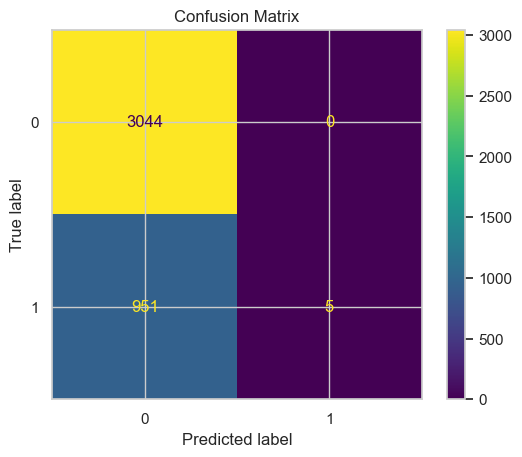

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows:

True Positive (TP) – correctly predicted approved loans
True Negative (TN) – correctly predicted denied loans
False Positive (FP) – incorrectly predicted approved
False Negative (FN) – incorrectly predicted denied

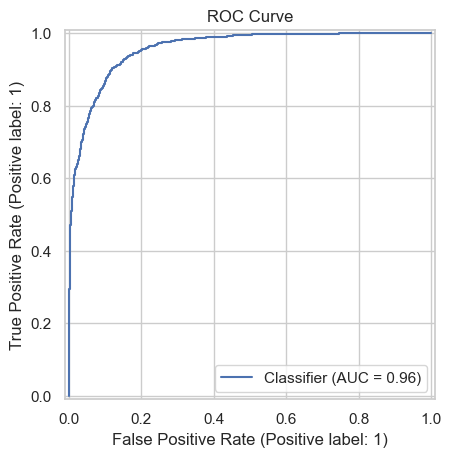

In [30]:
from sklearn.metrics import RocCurveDisplay

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.title("ROC Curve")
plt.show()

In [31]:
# Add predictions to test data
evaluation = X_test.copy()
evaluation["Actual"] = y_test.values
evaluation["Predicted"] = y_pred

# Performance by employment status
segment_results = []

for group, data in evaluation.groupby("EmploymentStatus"):
    segment_results.append({
        "EmploymentStatus": group,
        "Accuracy": accuracy_score(data["Actual"], data["Predicted"]),
        "Precision": precision_score(data["Actual"], data["Predicted"], zero_division=0),
        "Recall": recall_score(data["Actual"], data["Predicted"], zero_division=0)
    })

segment_results = pd.DataFrame(segment_results)
display(segment_results)

,EmploymentStatus,Accuracy,Precision,Recall
0,Employed,0.758965,1.0,0.004854
1,Self-Employed,0.736334,0.0,0.000000
2,Unemployed,0.829268,1.0,0.020000


Performance was also checked across employment groups to identify differences in model performance. This can help identify possible bias or groups that may need further investigation.


In [32]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = best_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
25,num__TotalDebtToIncomeRatio,0.169602
18,num__MonthlyIncome,0.168121
23,num__InterestRate,0.059801
22,num__BaseInterestRate,0.047767
3,num__LoanAmount,0.041412
21,num__NetWorth,0.029793
24,num__MonthlyLoanPayment,0.028334
16,num__TotalAssets,0.026868
14339,cat__EducationLevel_High School,0.019748
4,num__LoanDuration,0.019499


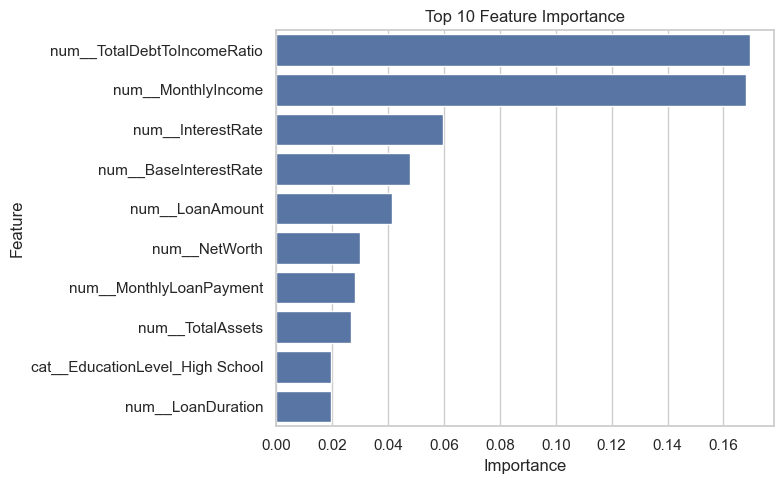

In [33]:
# Top 10 features
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()

Feature importance was used to identify which variables had the most influence on the Random Forest model. The most important features can help explain the factors linked to loan approval and support business decisions.


Executive Summary

The model was developed to predict loan approval using applicant and financial information. Three classification models were compared using cross-validation, and Random Forest was tuned using RandomizedSearchCV. The final model was evaluated using precision, recall, F1-score, and ROC-AUC.


Recommendations

The model can be used as a support tool for loan officers. The most important features should be reviewed to understand approval decisions. Model performance should also be monitored regularly and updated when new loan data becomes available.


Potential Improvements

The model is based on historical loan data, so changes in customer behaviour may affect future performance. Further improvement could include more recent data, additional feature engineering, and regular model monitoring.
